# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [3]:
import pandas as pd
train_fname = 'tweet_sentiment_train.csv.zip'
raw_df = pd.read_csv(train_fname)
raw_df = raw_df.dropna()
display(raw_df.head(5)), raw_df.info()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
dtypes: object(4)
memory usage: 1.0+ MB


(None, None)

In [11]:
raw_df.columns

Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [15]:
raw_df['sentiment'].value_counts()

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

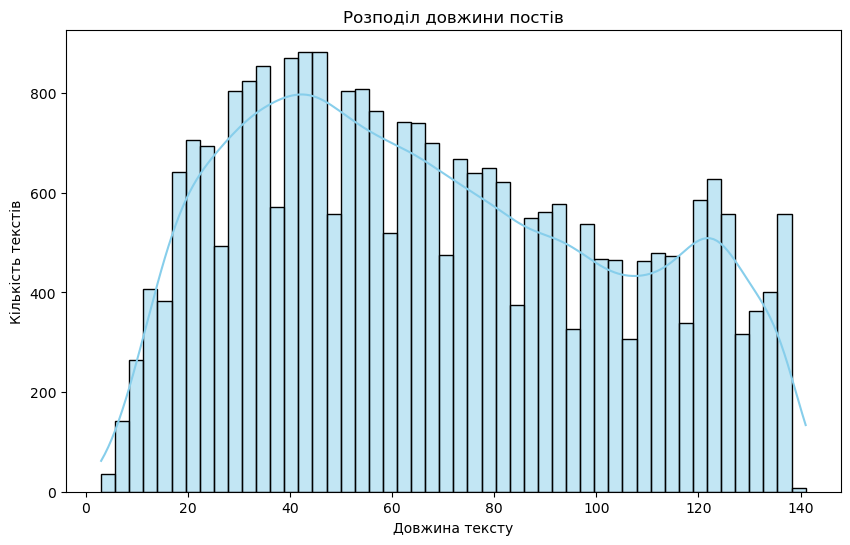

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(raw_df["text"].str.len(), bins=50, kde=True, color="skyblue")
plt.title("Розподіл довжини постів")
plt.xlabel("Довжина тексту")
plt.ylabel("Кількість текстів")
plt.show()

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [5]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
from collections import Counter
import nltk
import pandas as pd

nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")

def stem_tokenizer_no_stop(text):
    tokens = word_tokenize(text.lower())
    stems = [stemmer.stem(token) for token in tokens if token.isalpha() and token not in stop_words]
    return stems

all_tokens = []
for text in raw_df["text"]:
    all_tokens.extend(stem_tokenizer_no_stop(text))

word_freq = Counter(all_tokens)

print(f"Унікальних слів: {len(word_freq)}")
print(word_freq.most_common(20))
freq_df = pd.DataFrame(word_freq.items(), columns=["word", "count"]).sort_values(by="count", ascending=False)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Унікальних слів: 17783
[('day', 2417), ('go', 2373), ('get', 1911), ('good', 1589), ('work', 1521), ('love', 1478), ('like', 1457), ('got', 1258), ('http', 1243), ('today', 1149), ('time', 1095), ('one', 1067), ('lol', 1015), ('happi', 1010), ('want', 983), ('thank', 977), ('know', 975), ('miss', 964), ('u', 944), ('realli', 915)]


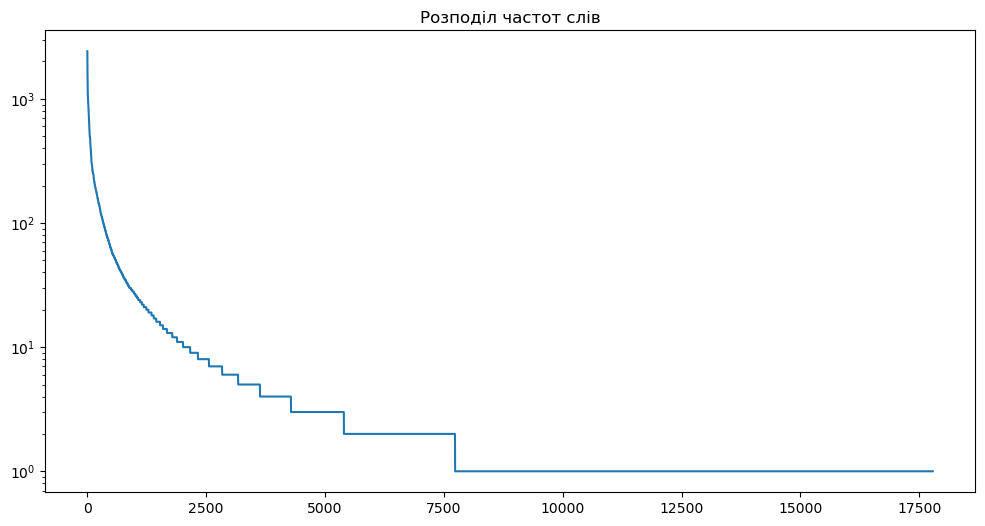

In [45]:
plt.figure(figsize=(12,6))
plt.plot(freq_df["count"].values)
plt.yscale("log")
plt.title("Розподіл частот слів")
plt.show()

5000 найчастіших слів перекриють більгу частину тексту

In [11]:
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer

stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))
noise_words = {'aaaah','aaah', 'aaahhh', 'aah', 'ah', 'aha', 'ahah','ahaha','ahhhhhhh', 'ahahah', 'ahahaha', 'ahh', 'ahhh', 'ahhhh', 'ahhhhh', 'ahhhhhh', 'alll', 'allll', 'alllll', 'awhil', 'awkward', 
               'aww', 'awww', 'awwww', 'awwwww', 'ay', 'booo', 'boooo', 'booooo', 'boooooo', 'boooooooo', 'hah', 'haha', 'hahaa', 'hahah', 'hahaha', 
               'hahahah', 'hahahaha', 'hahahahaha', 'hahahha', 'hee', 'heeey', 'heehe', 'heel', 'heh', 'hehe', 'heheh', 'heheheh', 'heheheheh', 'hm',
               'hmm', 'hmmm', 'hmmmm', 'mm', 'mmm', 'mmmm', 'mmmmm', 'mmmmmm', 'nooo', 'noooo', 'nooooo', 'noooooo', 'nooooooo', 'noooooooo', 
               'nooooooooo', 'ooo', 'oooh', 'oooo', 'ooooh', 'ooooo', 'tooo', 'toooo', 'tooooo'}

def stem_tokenizer(text):
    tokens = word_tokenize(text.lower()) 
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    stems = [stemmer.stem(token) for token in tokens if token.isalpha()] 
    tokens = [t for t in stems if t not in noise_words] 
    return tokens

vectorizer = CountVectorizer(tokenizer=stem_tokenizer, stop_words=None, max_features=5000)
X = vectorizer.fit_transform(raw_df["text"])

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [106]:
all_words = vectorizer.get_feature_names_out()
print(len(all_words))     
print(all_words[:200])    

5000
['aaron' 'ab' 'abandon' 'abbi' 'abil' 'abit' 'abl' 'absolut' 'abt' 'abus'
 'ac' 'academi' 'accept' 'access' 'accid' 'accident' 'accomplish' 'accord'
 'account' 'acct' 'ace' 'ach' 'achiev' 'acid' 'ack' 'across' 'act'
 'action' 'activ' 'actor' 'actress' 'actual' 'ad' 'adam' 'add' 'addict'
 'addit' 'address' 'admir' 'admit' 'adopt' 'ador' 'adult' 'advanc'
 'advantag' 'adventur' 'advert' 'advertis' 'advic' 'affect' 'afford'
 'afraid' 'africa' 'afternoon' 'afterward' 'age' 'agent' 'agh' 'ago'
 'agre' 'ahead' 'aidan' 'aiden' 'aight' 'aim' 'aint' 'air' 'airlin'
 'airport' 'aj' 'aka' 'ako' 'al' 'ala' 'alarm' 'alaska' 'album' 'alcohol'
 'alex' 'alexand' 'alexi' 'algebra' 'ali' 'alic' 'alien' 'alik' 'aliv'
 'allah' 'allen' 'allerg' 'allergi' 'alley' 'allow' 'almond' 'almost'
 'alo' 'aloha' 'alon' 'along' 'alot' 'aloud' 'alpha' 'alpin' 'alreadi'
 'alright' 'also' 'altern' 'although' 'alway' 'alyssa' 'amanda' 'amaz'
 'amazon' 'amber' 'amen' 'america' 'american' 'ami' 'amo' 'amongst'
 'amount'

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

y = raw_df["sentiment"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train_bow, X_test_bow, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2]) 

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='ovr'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss", 
        use_label_encoder=False, 
        random_state=42
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train_bow, y_train)
    y_proba = model.predict_proba(X_test_bow)
    
    auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
    
    # сохраняем не только метрику, но и саму модель
    results[name] = {
        "auc": auc,
        "model": model,
        "proba": y_proba
    }
    print(f"{name}: ROC-AUC = {auc:.3f}")

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression: ROC-AUC = 0.832
Decision Tree: ROC-AUC = 0.743
Random Forest: ROC-AUC = 0.841
Gradient Boosting: ROC-AUC = 0.802


C:\Users\hp\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:56:47] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: ROC-AUC = 0.837


In [25]:
print("\n📊 Таблиця по AUC:")

for name, info in sorted(results.items(), key=lambda x: x[1]["auc"], reverse=True):
    print(f"{name:20s}: {info['auc']:.3f}")


📊 Таблиця по AUC:
Random Forest       : 0.841
XGBoost             : 0.837
Logistic Regression : 0.832
Gradient Boosting   : 0.802
Decision Tree       : 0.743


In [32]:
from sklearn.metrics import classification_report
rf_model = results["Random Forest"]["model"]
print(classification_report(y_test, rf_model.predict(X_test_bow)))

              precision    recall  f1-score   support

           0       0.70      0.63      0.66      2334
           1       0.67      0.68      0.67      3335
           2       0.72      0.78      0.75      2575

    accuracy                           0.69      8244
   macro avg       0.70      0.69      0.69      8244
weighted avg       0.69      0.69      0.69      8244



Досить непоганий результат моделі, краще всього вона визначає клас "positive". І гірше всього знаходить нейтральні коментарі

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [36]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=vectorizer.get_feature_names_out(),  
    name='importance'
).sort_values(ascending=False)

feature_importance

love       0.027141
thank      0.022502
good       0.018317
happi      0.015003
miss       0.014892
             ...   
bai        0.000000
yawn       0.000000
sass       0.000000
awesome    0.000000
leed       0.000000
Name: importance, Length: 5000, dtype: float64

Я вивела ознаки які просто мають вплив на рішення моделі, без уточнення до якого класса належать здебільшого.
Виглядає логічно, тому що на початку списку емоційно забарвлені слова, а в кінці - нейтральні.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizerTF = TfidfVectorizer(tokenizer=stem_tokenizer, max_features=5000)
X = vectorizerTF.fit_transform(raw_df["text"])
y = raw_df["sentiment"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2]) 
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)
RF_model = RandomForestClassifier(n_estimators=200, random_state=42)
RF_model.fit(X_train_bow, y_train)
y_proba = RF_model.predict_proba(X_test_bow)
auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
auc

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


0.8463886629858686

Якість покращілась, не можна сказати що значно, але стала краща

In [66]:
feature_importance_ = pd.Series(
    RF_model.feature_importances_,
    index=vectorizer.get_feature_names_out(),  
    name='importance'
).sort_values(ascending=False)

feature_importance_

love     0.027781
thank    0.022380
good     0.019513
happi    0.015501
miss     0.015334
           ...   
yan      0.000000
yawn     0.000000
fewer    0.000000
drown    0.000000
lime     0.000000
Name: importance, Length: 5000, dtype: float64

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [88]:
raw_df['prediction_proba'] = RF_model.predict_proba(X)

In [90]:
raw_df.sentiment.value_counts()

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

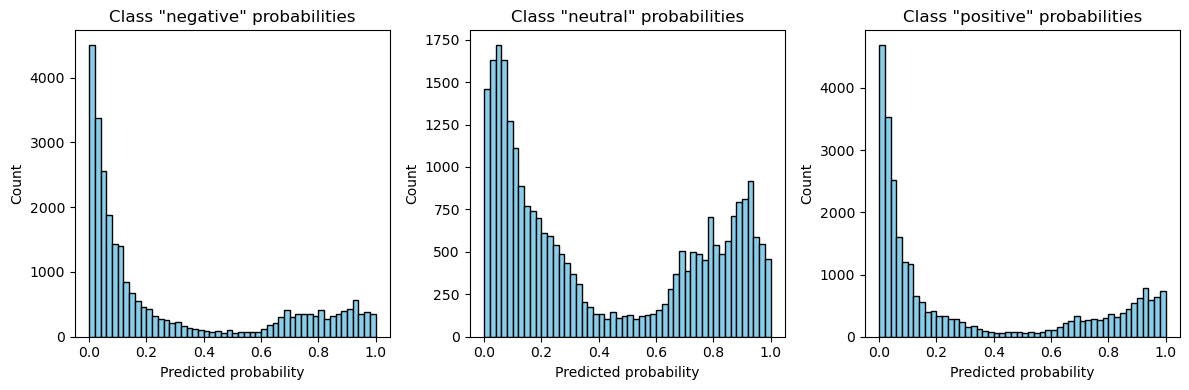

In [100]:
import matplotlib.pyplot as plt
import numpy as np

probs = RF_model.predict_proba(X)
class_names = ['negative', 'neutral', 'positive']

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.hist(probs[:, i], bins=50, color='skyblue', edgecolor='black')
    plt.title(f'Class "{class_names[i]}" probabilities')
    plt.xlabel('Predicted probability')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [128]:
import pandas as pd
import numpy as np


y_pred = RF_model.predict(X)
errors_df = pd.DataFrame({
    "text": raw_df["text"], 
    "selected_text": raw_df["selected_text"],
    "true_label": y,
    "pred_label": y_pred
})
errors_df["pred_label"] = errors_df["pred_label"].map(class_names)
errors_df = errors_df[errors_df["true_label"] != errors_df["pred_label"]]
class_names = {0: "negative", 1: "neutral", 2: "positive"}

errors_df[errors_df["true_label"] == "negative"].head(20)

,text,selected_text,true_label,pred_label
3,what interview! leave me alone,leave me alone,negative,neutral
4,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,neutral
12,My Sharpie is running DANGERously low on ink,DANGERously,negative,neutral
103,i realy wanted to go out cause its so nice but...,busy,negative,positive
123,Poor you Get outside and sleep in the garden...,Poor you,negative,positive
124,not well,not well,negative,neutral
172,URL in previous post (to timer job) should be ...,messed,negative,neutral
175,or even NOOOOO NOT THE SECRET NAMEREBECCA PLEASE,NOT THE SECRET NAMEREBECCA PLEASE,negative,neutral
340,I am lost. Please help me find a good home.,I am lost.,negative,neutral
358,this is sooo crazy i have fever..,this is sooo crazy,negative,neutral


In [138]:
df_analysis = pd.DataFrame({
    "true_label": y,
    "pred_label": y_pred
})
df_analysis["pred_label"] = df_analysis["pred_label"].map(class_names)
df_analysis["error"] = df_analysis["true_label"] != df_analysis["pred_label"]

error_rate = df_analysis.groupby("true_label")["error"].mean()
print(error_rate)

true_label
negative    0.121964
neutral     0.086174
positive    0.080284
Name: error, dtype: float64


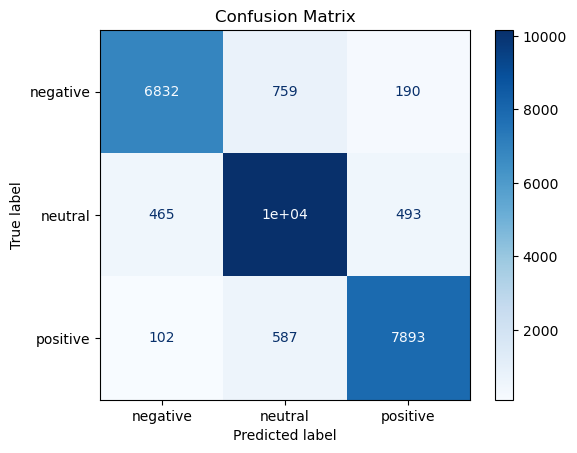

In [142]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_encoded, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["negative", "neutral", "positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Модель гірше визначає негативні коментарі, можна додати таких випадків в дані для навчання
Ми досить часто позитивні та негативні класи визначаємо нейтральними. Хоча, коли визначаються три класи не використовується трешхолд, обирається той клас в якого вище ймовірнвсть. Можна спробувати, визначати клас позитивним чи негативним частіше, якщо на це є певна ймовірність, навіть якщо вона меньше за нейтральну.
Можна додати біграмми або триграмми тоді модель зможе вловлювати контекст

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model